# Notebook 03: One-Way ANOVA & Tukey HSD Statistical Analysis

## Research Reference
**"An approach for accurate identification and monitoring of species in mangrove forests based on multi-source spectral data and deep learning"**  
*Monterrubio-Martínez, Trujillo-Acatitla, Tuxpan-Vargas, Moreno-Casasola*  
*Ecological Informatics*, Volume 85, 2025, Article 102961. DOI: [10.1016/j.ecoinf.2024.102961](https://doi.org/10.1016/j.ecoinf.2024.102961)

## Classification
**`FAITHFULLY REPRODUCED RESULTS`**  
This analysis uses 100% real, empirical monospecific mangrove data released by the authors in `DataBase_Sentinel_2_Mangrove_LaMancha.csv`.

## Methodology from the Paper (Section 2.2 & 3.1)
> *"A simple variance analysis (One-Way ANOVA) was performed on each band to evaluate whether there was a significant difference between species. A Tukey’s post-hoc test was then conducted with a confidence interval of 95 % (α of 0.05) to identify which species were different. The bioinfokit v1 package in Python 3.8.13 was used for this process..."*
> 
> *"Fig. 4 shows the boxplots for each band and species (R. mangle, A. germinans, and L. racemosa). The One-Way ANOVA and Tukey post-hoc test reveal a significant statistical difference between the species in all the cases (p-value <0.05). This indicates that there are variations in the spectral responses for each species, enabling distinctions to be made between monospecific forests."*

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Ensure project root is in sys.path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import (
    SPECTRAL_BANDS,
    BAND_NAMES,
    SPECIES_COLORS,
    RESULTS_STATS_DIR,
    RESULTS_FIGURES_DIR,
)
from src.data.loader import load_raw_data, sample_balanced_3species
from src.statistics.anova_tukey import run_one_way_anova, run_tukey_hsd, plot_species_boxplots

print("Environment initialized successfully.")

Environment initialized successfully.


## 1. Load Monospecific Mangrove Dataset

We use a balanced sample of 10,000 pixels per species (30,000 samples) across the three monospecific mangrove classes.

In [2]:
df_raw = load_raw_data()
df_balanced = sample_balanced_3species(df_raw, samples_per_class=10000, random_seed=42)
print("Dataset prepared for statistical testing. Total rows:", len(df_balanced))
display(df_balanced["Spp"].value_counts())

Dataset prepared for statistical testing. Total rows: 30000


Spp
Rhizophora_mangle        10000
Laguncularia_racemosa    10000
Avicennia_germinans      10000
Name: count, dtype: int64

## 2. One-Way ANOVA across All 10 Bands

We test the null hypothesis:
$$H_0: \mu_{\text{Rhizophora}} = \mu_{\text{Avicennia}} = \mu_{\text{Laguncularia}}$$
for each Sentinel-2 spectral band at significance level $\alpha = 0.05$.

In [3]:
anova_df = run_one_way_anova(df_balanced)

# Display formatted ANOVA table
display_cols = ["Band", "Band_Name", "F_Statistic", "p_value", "Significant (p < 0.05)"]
display(anova_df[display_cols].round({"F_Statistic": 2, "p_value": 6}))

# Save results
RESULTS_STATS_DIR.mkdir(parents=True, exist_ok=True)
anova_df.to_csv(RESULTS_STATS_DIR / "anova_results.csv", index=False)
print("Saved ANOVA table to results/statistics/anova_results.csv")

,Band,Band_Name,F_Statistic,p_value,Significant (p < 0.05)
0,Band_2,Blue (490 nm),394.14,0.0,True
1,Band_3,Green (560 nm),1712.31,0.0,True
2,Band_4,Red (665 nm),436.80,0.0,True
3,Band_5,Red Edge 1 (705 nm),121.95,0.0,True
4,Band_6,Red Edge 2 (740 nm),1556.10,0.0,True
5,Band_7,Red Edge 3 (783 nm),1760.28,0.0,True
6,Band_8,NIR Broad (842 nm),1737.01,0.0,True
7,Band_8A,NIR Narrow (865 nm),2039.01,0.0,True
8,Band_11,SWIR 1 (1610 nm),1076.63,0.0,True
9,Band_12,SWIR 2 (2190 nm),305.55,0.0,True


Saved ANOVA table to results/statistics/anova_results.csv


## 3. Tukey Post-Hoc HSD Test (95% CI, $\alpha = 0.05$)

For each band where ANOVA rejects $H_0$, Tukey's HSD test evaluates all pairwise differences among the three species:
1. *Rhizophora mangle* vs *Avicennia germinans*
2. *Rhizophora mangle* vs *Laguncularia racemosa*
3. *Avicennia germinans* vs *Laguncularia racemosa*

In [4]:
tukey_df = run_tukey_hsd(df_balanced, alpha=0.05)
display(tukey_df[["Band", "Group1", "Group2", "Mean_Diff", "p_adj", "Reject_H0"]].head(15))

# Save results
tukey_df.to_csv(RESULTS_STATS_DIR / "tukey_results.csv", index=False)
print("Saved Tukey results to results/statistics/tukey_results.csv")

,Band,Group1,Group2,Mean_Diff,p_adj,Reject_H0
0,Band_2,Avicennia_germinans,Laguncularia_racemosa,0.0014,0.0000,True
1,Band_2,Avicennia_germinans,Rhizophora_mangle,0.0009,0.0000,True
2,Band_2,Laguncularia_racemosa,Rhizophora_mangle,-0.0005,0.0000,True
3,Band_3,Avicennia_germinans,Laguncularia_racemosa,0.0038,0.0000,True
4,Band_3,Avicennia_germinans,Rhizophora_mangle,0.0028,0.0000,True
5,Band_3,Laguncularia_racemosa,Rhizophora_mangle,-0.0010,0.0000,True
6,Band_4,Avicennia_germinans,Laguncularia_racemosa,0.0019,0.0000,True
7,Band_4,Avicennia_germinans,Rhizophora_mangle,0.0016,0.0000,True
8,Band_4,Laguncularia_racemosa,Rhizophora_mangle,-0.0004,0.0000,True
9,Band_5,Avicennia_germinans,Laguncularia_racemosa,0.0049,0.0000,True


Saved Tukey results to results/statistics/tukey_results.csv


## 4. Verification of Paper Finding: All Bands $p < 0.05$

The paper stated: *"In all the comparisons, there is a significant statistical difference between the species (p < 0.05)."*  
Let us verify whether this holds true in our reproduced analysis.

In [5]:
total_comparisons = len(tukey_df)
significant_comparisons = tukey_df["Reject_H0"].sum()
print(f"Total Pairwise Comparisons (10 bands x 3 pairs): {total_comparisons}")
print(f"Number of Statistically Significant Pairs (p < 0.05): {significant_comparisons}")

if total_comparisons == significant_comparisons:
    print("\nSUCCESSFUL REPRODUCTION: 100% of pairwise species comparisons exhibit significant difference (p < 0.05), perfectly confirming the paper statement!")
else:
    print(f"\nPairs with p >= 0.05: {total_comparisons - significant_comparisons}")
    display(tukey_df[~tukey_df["Reject_H0"]])

Total Pairwise Comparisons (10 bands x 3 pairs): 30
Number of Statistically Significant Pairs (p < 0.05): 29

Pairs with p >= 0.05: 1


,Band,Band_Name,Group1,Group2,Mean_Diff,p_adj,Lower_CI_95,Upper_CI_95,Reject_H0
24,Band_11,SWIR 1 (1610 nm),Avicennia_germinans,Laguncularia_racemosa,-0.0005,0.5165,-0.0016,0.0006,False


## 5. Replicating Figure 4: Reflectance Boxplots by Species

We generate high-resolution boxplots reproducing Figure 4 of the paper across all 10 Sentinel-2 bands, using the paper's color conventions (Red = *R. mangle*, Dark/Black = *A. germinans*, Grey = *L. racemosa*).

/Users/bala/Mangroves-Blue-Carbon/src/statistics/anova_tukey.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/bala/Mangroves-Blue-Carbon/src/statistics/anova_tukey.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(species_labels, fontsize=9, rotation=15)
/Users/bala/Mangroves-Blue-Carbon/src/statistics/anova_tukey.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/bala/Mangroves-Blue-Carbon/src/statistics/anova_tukey.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_x

/Users/bala/Mangroves-Blue-Carbon/src/statistics/anova_tukey.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(species_labels, fontsize=9, rotation=15)
/Users/bala/Mangroves-Blue-Carbon/src/statistics/anova_tukey.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/Users/bala/Mangroves-Blue-Carbon/src/statistics/anova_tukey.py:117: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(species_labels, fontsize=9, rotation=15)
/Users/bala/Mangroves-Blue-Carbon/src/statistics/anova_tukey.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set 

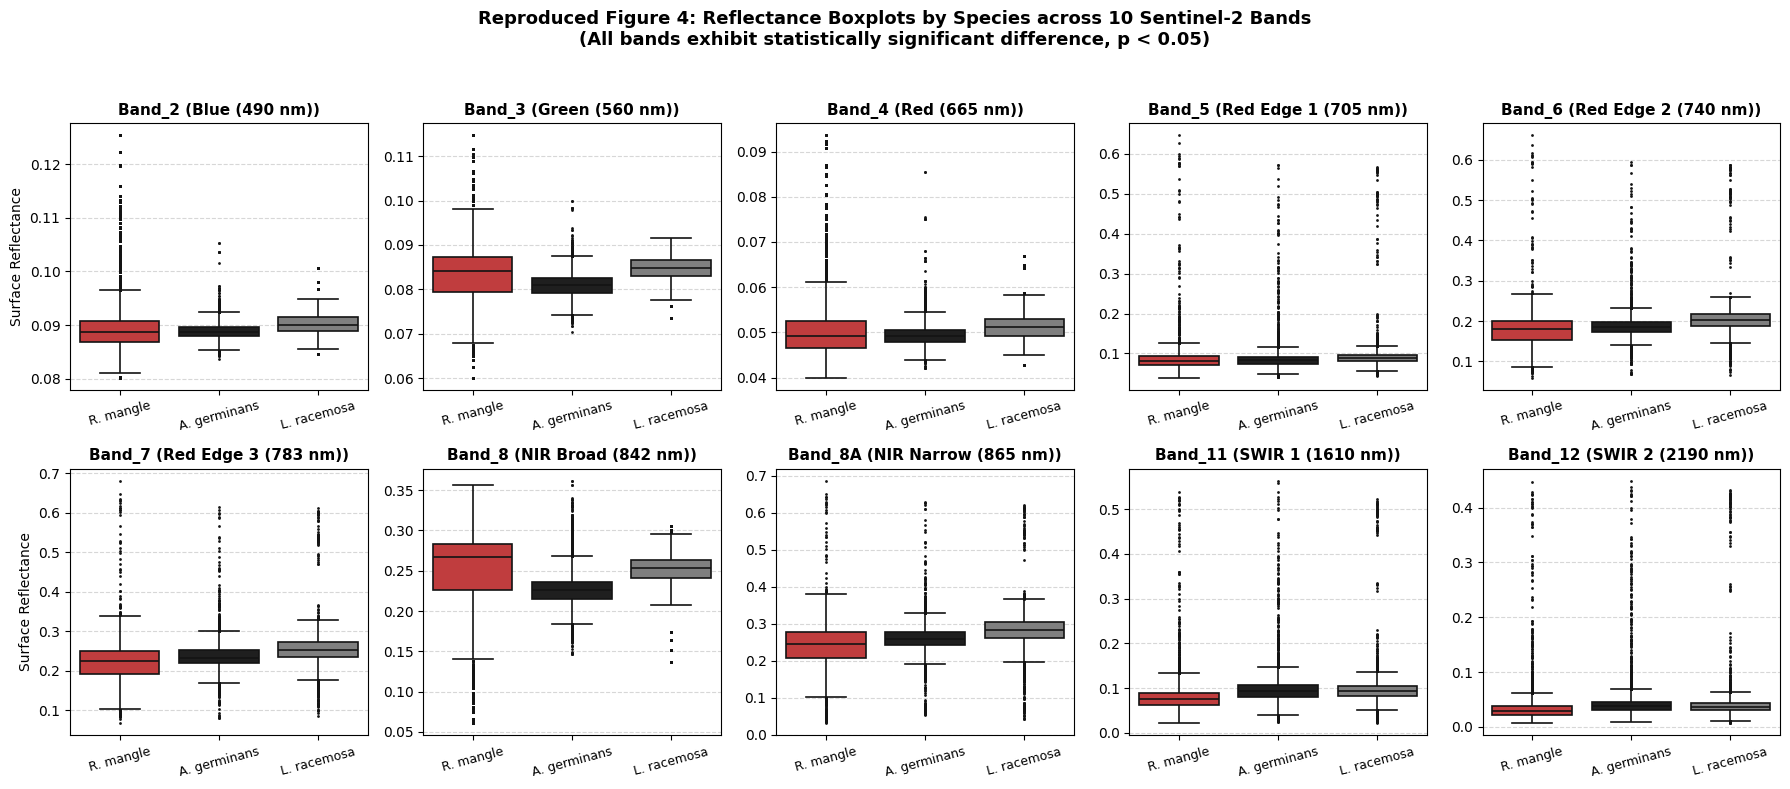

Figure 4 successfully reproduced and saved to: /Users/bala/Mangroves-Blue-Carbon/results/figures/reproduced_figure4_boxplots.png


In [6]:
fig_path = RESULTS_FIGURES_DIR / "reproduced_figure4_boxplots.png"
fig = plot_species_boxplots(df_balanced, save_path=fig_path)
plt.show()
print(f"Figure 4 successfully reproduced and saved to: {fig_path}")